# WM 2026 — Monte-Carlo-Simulation (Phase 2)

**Ziel:** aus den Einzelspiel-Wahrscheinlichkeiten (Ebene A aus Notebook 1) die
eigentliche **Titelprognose** machen (Ebene C) — durch tausendfaches Durchsimulieren
des kompletten Turniers.

Wir bauen das **echte 48-Team-Format** der WM 2026 nach: 12 Vierergruppen, jeder
gegen jeden, dann die K.-o.-Phase mit den beiden Gruppenbesten plus den **8 besten
Gruppendritten** (insgesamt 32 Teams ab Sechzehntelfinale).

**Vorgehen:** Daten laden → Dixon-Coles auf allen Daten bis WM-Start fitten → echte
Gruppen rekonstruieren → Score-Verteilungen vorberechnen → 10'000 Turniere
simulieren → zaehlen, wie oft jedes Team Weltmeister wird.

> **Wichtig vorab — zwei bekannte Grenzen dieser v1 (am Ende ausfuehrlich):**
> 1. Gruppenphase + Qualifikation sind **exakt** (echte Auslosung, echte Regeln).
> 2. Das Modell **ueberschaetzt Teams aus schwaecheren Konfoederationen** — die
>    Baseline-Schwaeche aus Notebook 1. Fix = Phase 4 (Elo-Features).
> 3. Das K.-o.-**Bracket** ist nach Gruppenfinish geseedet (Platzhalter fuer das
>    offizielle FIFA-Bracket).

## 1. Setup & Daten laden

Wir brauchen zusaetzlich `networkx`, um die Gruppen aus den Spielpaarungen zu
rekonstruieren. Falls nicht installiert: `pip install networkx`.

**Zwei Datensichten — entscheidender Punkt:**
- `df_all` = **alle** Zeilen inkl. der WM-2026-Fixtures (die haben noch *leere*
  Resultate) → daraus lesen wir Spielplan und Gruppen.
- `train` = nur **abgeschlossene** Spiele vor WM-Start → darauf fittet das Modell.

Wuerden wir gleich beim Laden `dropna()` machen, fielen die WM-2026-Fixtures weg und
wir koennten die Gruppen nicht rekonstruieren.

In [2]:
import numpy as np
import pandas as pd
import networkx as nx
import string
import time
from pathlib import Path
from scipy.optimize import minimize
from scipy.stats import poisson
import matplotlib.pyplot as plt

DATA_URL = ("https://raw.githubusercontent.com/martj42/"
            "international_results/master/results.csv")
LOCAL = Path("../data/results.csv")

if LOCAL.exists():
    df_all = pd.read_csv(LOCAL, parse_dates=["date"])
    print(f"Lokale Datei geladen: {LOCAL}")
else:
    LOCAL.parent.mkdir(parents=True, exist_ok=True)
    for attempt in range(1, 4):
        try:
            df_all = pd.read_csv(DATA_URL, parse_dates=["date"])
            df_all.to_csv(LOCAL, index=False)   # fuer naechstes Mal cachen
            print(f"Vom GitHub-Mirror geladen und gecached -> {LOCAL}")
            break
        except Exception as e:
            print(f"Versuch {attempt}/3 fehlgeschlagen: {e}")
    else:
        raise RuntimeError("Konnte results.csv nicht laden")

REF = pd.Timestamp("2026-06-11")        # WM-2026-Start = Stichtag

# Trainingsdaten: nur abgeschlossene Spiele vor dem Turnier, ab 2010
df = df_all.dropna(subset=["home_score", "away_score"]).copy()
df["home_score"] = df["home_score"].astype(int)
df["away_score"] = df["away_score"].astype(int)
train = df[(df["date"] < REF) & (df["date"] >= "2010-01-01")].copy()

print(f"Trainingsspiele: {len(train):,}")

Vom GitHub-Mirror geladen und gecached -> ..\data\results.csv
Trainingsspiele: 15,670


## 2. Dixon-Coles-Modell fitten (Vorhersage-Engine aus Notebook 1)

Identischer Code wie in Notebook 1 — nur trainieren wir hier auf **allen** Daten bis
zum WM-Start, damit die Teamstaerken den aktuellen Stand widerspiegeln. Der Fit
dauert ~30 Sekunden (rund 300 Teams, also ~600 Parameter).

> `success = False` ist wieder erwartet und harmlos (flache Mittelwert-Richtung der
> Angriffsparameter).

In [3]:
teams = sorted(set(train["home_team"]) | set(train["away_team"]))
idx = {t: i for i, t in enumerate(teams)}
n = len(teams)

hi = train["home_team"].map(idx).values
ai = train["away_team"].map(idx).values
hg = train["home_score"].values
ag = train["away_score"].values
neutral = train["neutral"].values.astype(float)
weights = np.exp(-0.0018 * (REF - train["date"]).dt.days.values)   # Zeitgewicht


def dc_tau(x, y, lam, mu, rho):
    '''Dixon-Coles-Korrektur fuer niedrige Resultate (vektorisiert).'''
    t = np.ones_like(lam)
    m = (x == 0) & (y == 0); t[m] = 1 - lam[m] * mu[m] * rho
    m = (x == 0) & (y == 1); t[m] = 1 + lam[m] * rho
    m = (x == 1) & (y == 0); t[m] = 1 + mu[m] * rho
    m = (x == 1) & (y == 1); t[m] = 1 - rho
    return np.clip(t, 1e-10, None)


def neg_log_likelihood(p):
    att = p[:n] - p[:n].mean()                 # Angriff zentrieren (Identifizierbarkeit)
    deff = p[n:2*n]
    home_adv = p[2*n]
    rho = p[2*n + 1]
    lam = np.exp(att[hi] + deff[ai] + home_adv * (1 - neutral))
    mu = np.exp(att[ai] + deff[hi])
    ll = (np.log(dc_tau(hg, ag, lam, mu, rho))
          + poisson.logpmf(hg, lam) + poisson.logpmf(ag, mu))
    return -np.sum(weights * ll)


t0 = time.time()
p0 = np.concatenate([np.zeros(n), np.zeros(n), [0.25, -0.1]])
res = minimize(neg_log_likelihood, p0, method="L-BFGS-B", options={"maxiter": 400})

att = res.x[:n] - res.x[:n].mean()
deff = res.x[n:2*n]
rho = res.x[2*n + 1]
print(f"Fit in {time.time()-t0:.0f}s, {n} Teams, rho={rho:.3f}")

Fit in 40s, 312 Teams, rho=-0.140


## 3. Die echten Gruppen rekonstruieren

Der Datensatz enthaelt die 72 Gruppenspiele der WM 2026 (12 Gruppen x 6 Spiele,
11.–27. Juni) — aber **ohne** Gruppenbuchstaben. Wir leiten die Gruppen aus den
Paarungen ab: Innerhalb einer Gruppe spielt jeder gegen jeden, die 4 Teams bilden
also einen **vollstaendig verbundenen Graphen**. Mit `networkx` finden wir diese
"Zusammenhangskomponenten" = die Gruppen. Die Buchstaben A–L vergeben wir nach der
Reihenfolge des ersten Auftretens im Spielplan (Gruppe A eroeffnet das Turnier).

In [4]:
# Nur die Gruppenphase-Fixtures (mit echten Teamnamen, Resultate noch leer)
gs = df_all[(df_all["tournament"] == "FIFA World Cup")
            & (df_all["date"].between("2026-06-11", "2026-06-27"))]

# Graph: jede Paarung = eine Kante; jede Gruppe wird zur Zusammenhangskomponente
G = nx.Graph()
for _, r in gs.iterrows():
    G.add_edge(r["home_team"], r["away_team"])
comps = list(nx.connected_components(G))

# Buchstaben nach Reihenfolge des ersten Auftretens im Spielplan
order, seen = [], set()
for _, r in gs.sort_values("date").iterrows():
    for t in (r["home_team"], r["away_team"]):
        if t not in seen:
            seen.add(t); order.append(t)
comp_of = {t: i for i, c in enumerate(comps) for t in c}
first_idx = {}
for pos, t in enumerate(order):
    first_idx.setdefault(comp_of[t], pos)
labels = sorted(first_idx, key=lambda c: first_idx[c])

groups = {L: sorted(comps[c]) for L, c in zip(string.ascii_uppercase, labels)}
for L, g in groups.items():
    print(f"Gruppe {L}: {', '.join(g)}")

Gruppe A: Czech Republic, Mexico, South Africa, South Korea
Gruppe B: Bosnia and Herzegovina, Canada, Qatar, Switzerland
Gruppe C: Australia, Paraguay, Turkey, United States
Gruppe D: Brazil, Haiti, Morocco, Scotland
Gruppe E: Japan, Netherlands, Sweden, Tunisia
Gruppe F: Curaçao, Ecuador, Germany, Ivory Coast
Gruppe G: Belgium, Egypt, Iran, New Zealand
Gruppe H: Cape Verde, Saudi Arabia, Spain, Uruguay
Gruppe I: Algeria, Argentina, Austria, Jordan
Gruppe J: France, Iraq, Norway, Senegal
Gruppe K: Colombia, DR Congo, Portugal, Uzbekistan
Gruppe L: Croatia, England, Ghana, Panama


## 4. Score-Verteilungen vorberechnen (fuer Tempo)

10'000 Turniere x ~103 Spiele = ueber eine Million simulierte Partien. Wuerden wir
fuer jede Partie neu die Score-Matrix bauen, dauerte das ewig. Trick: Wir berechnen
**einmal** fuer jedes moegliche Paar der 48 Teams die Verteilung der Resultate (alle
Spiele neutral, kein Heimvorteil) und speichern sie als **kumulative Verteilung**.
Dann ist das Ausspielen einer Partie nur noch ein schnelles `searchsorted`.

Zusaetzlich `PADV[i,j]` = Wahrscheinlichkeit, dass Team i gewinnt, *gegeben dass es
keinen Gleichstand gibt* — das nutzen wir in der K.-o.-Phase als Naeherung fuer
Verlaengerung/Elfmeterschiessen.

In [5]:
wm_teams = [t for g in groups.values() for t in g]    # alle 48 in Gruppenreihenfolge
wi = {t: i for i, t in enumerate(wm_teams)}
M = len(wm_teams)

# Staerken aus dem Modell ziehen (unbekannte Teams: schwaechster Wert als Fallback)
A = np.array([att[idx[t]] if t in idx else att.min() for t in wm_teams])
D = np.array([deff[idx[t]] if t in idx else deff.max() for t in wm_teams])

MG = 11                                  # max. Tore pro Team in der Matrix
goals = np.arange(MG)
CUM = np.zeros((M, M, MG * MG))          # kumulative Score-Verteilung je Paar
PADV = np.zeros((M, M))                  # P(i gewinnt | kein Remis)

for i in range(M):
    for j in range(M):
        lam = np.exp(A[i] + D[j])        # neutral: kein Heimvorteil
        mu = np.exp(A[j] + D[i])
        SM = np.outer(poisson.pmf(goals, lam), poisson.pmf(goals, mu))
        SM[0, 0] *= 1 - lam * mu * rho   # Dixon-Coles-Korrektur
        SM[0, 1] *= 1 + lam * rho
        SM[1, 0] *= 1 + mu * rho
        SM[1, 1] *= 1 - rho
        SM /= SM.sum()
        CUM[i, j] = np.cumsum(SM.ravel())
        ph, pa = np.tril(SM, -1).sum(), np.triu(SM, 1).sum()
        PADV[i, j] = ph / (ph + pa)

print("Score-Verteilungen vorberechnet.")

Score-Verteilungen vorberechnet.


## 5. Spiel- und Sieger-Funktionen

`play` wuerfelt ein Resultat aus der vorberechneten Verteilung. `winner` ist fuer
die K.-o.-Phase: bei Gleichstand entscheidet `PADV` (das staerkere Team kommt
wahrscheinlicher weiter — unsere Naeherung fuer Verlaengerung/Elfmeter).

In [6]:
def play(i, j, rng):
    '''Ein Spiel ausspielen -> (Heimtore, Auswaertstore).'''
    flat = np.searchsorted(CUM[i, j], rng.random())
    return divmod(flat, MG)


def winner(i, j, rng):
    '''K.-o.-Spiel: gibt den Index des Siegers zurueck (kein Remis moeglich).'''
    h, a = play(i, j, rng)
    if h > a: return i
    if a > h: return j
    return i if rng.random() < PADV[i, j] else j


def seed_order(N):
    '''Standard-Setzreihenfolge fuer ein K.-o.-Bracket der Groesse N (Zweierpotenz).

    Sorgt dafuer, dass Setzkopf 1 und 2 erst im Finale aufeinandertreffen koennen.
    '''
    o = [1, 2]
    while len(o) < N:
        c = len(o) * 2 + 1
        o = [v for s in o for v in (s, c - s)]
    return o

SEED_ORDER = seed_order(32)

## 6. Ein komplettes Turnier simulieren

Schritt fuer Schritt:
1. **Gruppenphase:** in jeder Gruppe jeder gegen jeden (3 Punkte Sieg, 1 Remis),
   Tore mitzaehlen.
2. **Tabelle:** sortieren nach Punkten, dann Tordifferenz, dann erzielte Tore.
3. **Qualifikation:** die ersten zwei jeder Gruppe + die **8 besten Gruppendritten**
   (eigene Tabelle aller 12 Dritten nach denselben Kriterien).
4. **Bracket:** die 32 Teams nach Gruppenfinish setzen (Sieger > Zweite > Dritte) —
   *Platzhalter* fuer das offizielle FIFA-Bracket.
5. **K.-o.-Phase:** Sechzehntel → Achtel → Viertel → Halb → Finale.

Die Funktion gibt Weltmeister, die beiden Finalisten und die vier Halbfinalisten
zurueck.

In [7]:
def simulate(rng):
    third, qual = [], []

    # --- Gruppenphase ---
    for L, gt in groups.items():
        gi = [wi[t] for t in gt]
        pts = {k: 0 for k in gi}; gf = {k: 0 for k in gi}; ga = {k: 0 for k in gi}
        for a in range(4):                      # jeder gegen jeden (6 Spiele)
            for b in range(a + 1, 4):
                h, aw = play(gi[a], gi[b], rng)
                gf[gi[a]] += h; ga[gi[a]] += aw
                gf[gi[b]] += aw; ga[gi[b]] += h
                if h > aw:   pts[gi[a]] += 3
                elif aw > h: pts[gi[b]] += 3
                else:        pts[gi[a]] += 1; pts[gi[b]] += 1

        # Tabelle: Punkte > Tordifferenz > erzielte Tore
        rank = sorted(gi, key=lambda k: (pts[k], gf[k]-ga[k], gf[k]), reverse=True)
        for fin in (0, 1, 2):                   # 0=Sieger, 1=Zweiter, 2=Dritter
            tm = rank[fin]
            rec = (fin, pts[tm], gf[tm]-ga[tm], gf[tm], tm)
            (qual if fin < 2 else third).append(rec)

    # --- 8 beste Gruppendritte ---
    best3 = sorted(third, key=lambda x: (x[1], x[2], x[3]), reverse=True)[:8]

    # --- Bracket-Setzung nach Gruppenfinish (Platzhalter fuers offizielle Bracket) ---
    q = [r[4] for r in sorted(qual + best3, key=lambda x: (x[0], -x[1], -x[2], -x[3]))]
    seeds = {s: q[s - 1] for s in range(1, 33)}
    bracket = [seeds[SEED_ORDER[k]] for k in range(32)]

    # --- K.-o.-Phase ---
    sf = fin = None
    while len(bracket) > 1:
        if len(bracket) == 4: sf = list(bracket)    # Halbfinalisten
        if len(bracket) == 2: fin = list(bracket)   # Finalisten
        bracket = [winner(bracket[k], bracket[k+1], rng)
                   for k in range(0, len(bracket), 2)]

    return bracket[0], fin, sf

## 7. 10'000 Turniere simulieren

Jetzt der Monte-Carlo-Kern: viele unabhaengige Turnier-Durchlaeufe, dann mitteln.
Wir zaehlen pro Team, wie oft es Weltmeister wird, das Finale erreicht und das
Halbfinale erreicht — die relativen Haeufigkeiten *sind* die Wahrscheinlichkeiten.

In [8]:
N = 10_000
rng = np.random.default_rng(42)          # fester Seed -> reproduzierbar

champ = np.zeros(M); finalist = np.zeros(M); semi = np.zeros(M)
t0 = time.time()
for _ in range(N):
    c, f, s4 = simulate(rng)
    champ[c] += 1
    for x in f:  finalist[x] += 1
    for x in s4: semi[x] += 1
print(f"{N:,} Simulationen in {time.time()-t0:.1f}s")

result = (pd.DataFrame({"Team": wm_teams,
                        "Titel": champ / N,
                        "Finale": finalist / N,
                        "Halbfinale": semi / N})
          .sort_values("Titel", ascending=False)
          .reset_index(drop=True))

result.head(15).style.format({"Titel": "{:.1%}", "Finale": "{:.1%}",
                              "Halbfinale": "{:.1%}"})

10,000 Simulationen in 1.9s


,Team,Titel,Finale,Halbfinale
0,Argentina,24.9%,35.5%,48.8%
1,Spain,11.9%,21.2%,35.5%
2,Japan,11.3%,20.3%,34.4%
3,Morocco,9.9%,17.8%,30.3%
4,Brazil,9.2%,16.9%,29.4%
5,Colombia,5.6%,11.7%,22.1%
6,Ecuador,4.3%,9.6%,18.8%
7,France,3.3%,7.4%,16.3%
8,Australia,2.8%,7.1%,15.4%
9,England,2.3%,6.1%,13.9%


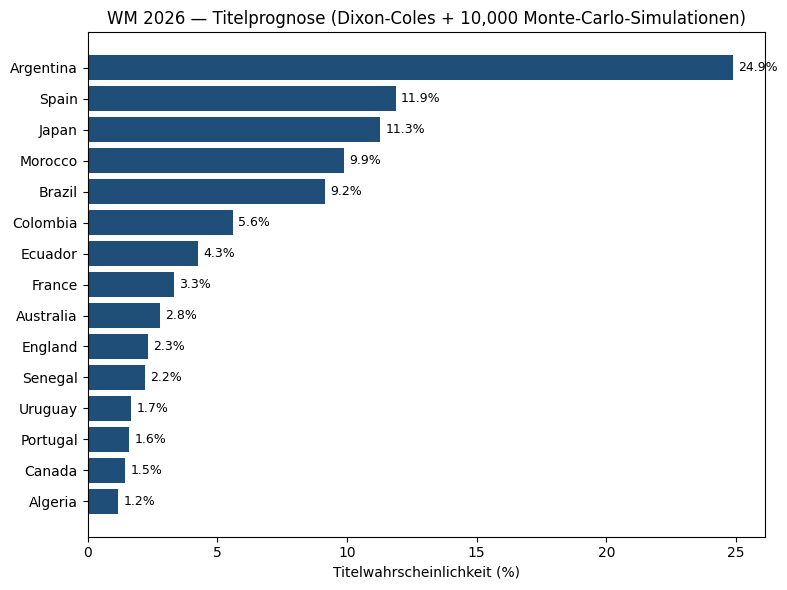

In [9]:
# Top 15 als Balkendiagramm
top = result.head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top["Team"], top["Titel"] * 100, color="#1f4e79")
ax.set_xlabel("Titelwahrscheinlichkeit (%)")
ax.set_title(f"WM 2026 — Titelprognose (Dixon-Coles + {N:,} Monte-Carlo-Simulationen)")
for i, v in enumerate(top["Titel"] * 100):
    ax.text(v + 0.2, i, f"{v:.1f}%", va="center", fontsize=9)
plt.tight_layout()
plt.show()

## 8. Interpretation — und drei ehrliche Grenzen

Argentinien als klarer Favorit ist plausibel (amtierender Weltmeister, Topform).
Aber das Modell ist eine **v1**, und drei Dinge solltest du im Kopf behalten:

**1. Gruppenphase + Qualifikation sind exakt.** Echte Auslosung, echte Regeln
(Top 2 + 8 beste Dritte). Hier vertrauen wir dem Modell voll.

**2. Das Modell ueberschaetzt Teams aus schwaecheren Konfoederationen.** Teams wie
Japan oder Marokko erscheinen zu hoch, Frankreich/England zu tief. Grund: Die
Baseline lernt nur aus Toren — wer in der Quali viele Tore gegen schwache Gegner
schiesst, wirkt staerker, als er gegen Top-Teams ist. **Fix = Phase 4** (Elo-/SPI-
Features statt nur Endresultate; das normalisiert die Gegnerstaerke).

**3. Das K.-o.-Bracket ist eine Naeherung.** Wir setzen die 32 Teams nach
Gruppenfinish; das echte FIFA-Bracket ordnet die Achtel/Sechzehntel und besonders
die 8 Dritten ueber eine feste Zuordnungstabelle. Das beeinflusst, wer wann auf wen
trifft. **Verfeinerung = Phase 2b** (offizielles Bracket einbauen).

**Warum trotzdem wertvoll?** Die Pipeline steht und ist korrekt: echte Gruppen,
echte Regeln, sauberer Monte-Carlo-Kern. Sobald die Engine in Phase 4 besser
kalibriert ist, liefert genau dieser Code deutlich realistischere Zahlen — ohne dass
sich die Struktur aendert.

## Naechste Schritte

- **Phase 2b:** offizielles FIFA-Bracket (inkl. Zuordnungstabelle der 8 Dritten)
  statt Finish-Seeding.
- **Phase 3:** TheSportsDB-Live-Schicht — waehrend des Turniers echte Resultate
  einspielen und die Restsimulation taeglich aktualisieren.
- **Phase 4:** Ebene-A-Upgrade mit Elo-/Form-Features (oder LightGBM), erneut per
  RPS gegen die Baseline messen — behebt die Konfoederations-Verzerrung.
- **Refactor:** Dixon-Coles-Fit in ein `src/dixon_coles.py`-Modul auslagern, das
  beide Notebooks importieren (statt den Fit zu duplizieren).